# American Put Pricing under the Black Scholes Model

Author: Jose Melo

## Imports

In [23]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from scipy.stats import norm
from optimizer import *
from nets import *
from fd import *
from matplotlib import cm
import json
import time
from torch.quasirandom import SobolEngine

%matplotlib inline

DTYPE = torch.float64
DEV   = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(DTYPE)

## Parameters

In [24]:
STRIKE = 1
S_MIN, S_MAX = 0, 4 * STRIKE
X_MIN, X_MAX = S_MIN, S_MAX
T = 1.0  # years to expiry
r = 0.03  # risk-free (flat)
q = 0.00  # dividend yield
SIGMA = 0.20  # volatility

In [25]:
def sample_domain(n_int=25_000, n_bdry=25_000, n_pay=25_000):
    # interior ----------------------------------------------------
    inter = np.random.rand(n_int, 2)
    inter[:, 0] = inter[:, 0] * T
    inter[:, 1] = inter[:, 1] * (X_MAX - X_MIN) + X_MIN

    # bottom boundary  x = X_MIN ------------------------------
    bot = np.random.rand(n_bdry, 2)
    bot[:, 0] = bot[:, 0] * T
    bot[:, 1] = X_MIN

    # top boundary  x = X_MAX -------------------------------
    top = np.random.rand(n_bdry, 2)
    top[:, 0] = top[:, 0] * T
    top[:, 1] = X_MAX

    # terminal condition  tau = 0 ------------------------------
    pay = np.random.rand(n_pay, 2)
    pay[:, 0] = 0.0
    pay[:, 1] = pay[:, 1] * (X_MAX - X_MIN) + X_MIN

    X = np.vstack([inter, bot, top, pay])
    return torch.tensor(X, dtype=DTYPE, device=DEV)


def sample_domain(
    n_int: int = 5_000, n_bdry: int = 5_000, n_pay: int = 5_000, scramble: bool = True
):
    eng_int = SobolEngine(dimension=2, scramble=scramble)
    inter = eng_int.draw(n_int)  # (n_int,2)  in (0,1)^2
    inter[:, 0] = inter[:, 0] * T  # τ  ∈ (0,T)
    inter[:, 1] = inter[:, 1] * (X_MAX - X_MIN) + X_MIN  # x  ∈ (X_MIN,X_MAX)

    # ── 2) bottom boundary  (x = X_MIN,  τ ∈ (0,T)) ─────────────
    eng_bot = SobolEngine(dimension=1, scramble=scramble)
    bot_tau = eng_bot.draw(n_bdry).squeeze(-1) * T
    bot = torch.stack([bot_tau, torch.full_like(bot_tau, X_MIN)], dim=1)

    # ── 3) top boundary  (x = X_MAX,  τ ∈ (0,T)) ────────────────
    eng_top = SobolEngine(dimension=1, scramble=scramble)
    top_tau = eng_top.draw(n_bdry).squeeze(-1) * T
    top = torch.stack([top_tau, torch.full_like(top_tau, X_MAX)], dim=1)

    # ── 4) payoff slice  (τ = 0,  x ∈ (X_MIN,X_MAX)) ────────────
    eng_pay = SobolEngine(dimension=1, scramble=scramble)
    pay_x = eng_pay.draw(n_pay).squeeze(-1) * (X_MAX - X_MIN) + X_MIN
    pay = torch.stack([torch.zeros_like(pay_x), pay_x], dim=1)

    # ── 5) concatenate & move to the right dtype/device ─────────
    X = torch.cat([inter, bot, top, pay], dim=0)
    return X.to(dtype=DTYPE, device=DEV)

In [26]:
def pde_residual(model, X):
    X.requires_grad_(True)
    u = model(X)
    tau, x = X.t()
    grads = torch.autograd.grad(u.sum(), X, create_graph=True)[0]
    u_tau, u_x = grads[:, 0], grads[:, 1]
    u_xx = torch.autograd.grad(u_x.sum(), X, create_graph=True)[0][:, 1]
    return -u_tau + 0.5 * SIGMA**2 * x**2 * u_xx + (r - q) * x * u_x, u


def pde_loss(model, X):
    _, x = X.t()
    H = torch.maximum(STRIKE - x, torch.zeros_like(x))
    pde, u = pde_residual(model, X)
    return torch.maximum(H - u, pde).pow(2).mean()


def loss_fn(model, X):
    tau, x = X.t()
    interior = (tau > 0) & (tau < T) & (x > X_MIN) & (x < X_MAX)
    bot = x == X_MIN
    top = x == X_MAX
    payoff = tau == 0

    # interior
    l_int = pde_loss(model, X[interior])

    V_top = model(X[top])
    l_top = V_top.pow(2).mean()

    # top boundary  d2V/dx2 - dV/dx = 0
    X_bot = X[bot].requires_grad_(True)
    V_bot = model(X_bot)
    Vx_bot = torch.autograd.grad(V_bot.sum(), X_bot, create_graph=True)[0][:, 1]
    Vxx_bot = torch.autograd.grad(Vx_bot.sum(), X_bot, create_graph=True)[0][:, 1]
    l_bot = (Vxx_bot).pow(2).mean()

    # payoff
    x_pay = x[payoff]
    payoff_val = torch.maximum(STRIKE - x_pay, torch.zeros_like(x_pay))
    l_pay = (model(X[payoff]) - payoff_val).pow(2).mean()

    print(
        "loss int {:8.2e}  bot {:8.2e}  top {:8.2e}  pay {:8.2e}".format(
            l_int.item(), l_bot.item(), l_top.item(), l_pay.item()
        )
    )
    return l_int, l_bot, l_top, l_pay

## Training

In [27]:
X = sample_domain()

In [ ]:
model = MLP(in_dim=2, hidden_layers=[60, 60, 60], out_dim=1).to(DEV)
for p in model.parameters():
    if p.dim() > 1:
        nn.init.xavier_uniform_(p)

benchmark = {
    "interior": [],
    "bottom": [],
    "top": [],
    "payoff": [],
    "total_loss": [],
    "time": 0.0,
}

In [29]:
opt = SSBroyden(
    model.parameters(), max_iter=20_000, tolerance_change=1e-30, tolerance_grad=1e-30
)

def closure(*args, **kwargs):
    opt.zero_grad()
    l_int, l_bot, l_top, l_pay = loss_fn(model, X)
    loss = l_int + l_bot + l_top + l_pay
    benchmark["interior"].append(l_int.item())
    benchmark["bottom"].append(l_bot.item())
    benchmark["top"].append(l_top.item())
    benchmark["payoff"].append(l_pay.item())
    benchmark["total_loss"].append(loss.item())
    loss.backward()
    return loss

start = time.time()
opt.step(closure)
end = time.time()
benchmark["time"] = end - start
print("training finished")

loss int 2.18e+00  bot 2.66e-05  top 1.94e+00  pay 2.06e+00
loss int 1.56e+00  bot 3.91e-05  top 1.33e+00  pay 1.45e+00
loss int 1.56e+00  bot 3.91e-05  top 1.33e+00  pay 1.45e+00
loss int 1.52e+00  bot 4.02e-05  top 1.30e+00  pay 1.41e+00
loss int 1.11e+00  bot 5.22e-05  top 9.57e-01  pay 1.01e+00
loss int 3.67e-02  bot 3.49e-04  top 7.07e-01  pay 9.31e-01
loss int 5.67e-02  bot 1.72e-04  top 2.44e-03  pay 5.07e-02
loss int 5.67e-02  bot 1.72e-04  top 2.44e-03  pay 5.07e-02
loss int 5.65e-02  bot 1.71e-04  top 2.44e-03  pay 5.05e-02
loss int 5.49e-02  bot 1.69e-04  top 2.49e-03  pay 4.94e-02
loss int 3.98e-02  bot 1.47e-04  top 1.02e-02  pay 4.01e-02
loss int 3.98e-02  bot 1.47e-04  top 1.02e-02  pay 4.01e-02
loss int 3.94e-02  bot 1.48e-04  top 1.01e-02  pay 4.01e-02
loss int 3.62e-02  bot 1.51e-04  top 9.30e-03  pay 4.07e-02
loss int 3.62e-02  bot 1.51e-04  top 9.30e-03  pay 4.07e-02
loss int 3.61e-02  bot 1.52e-04  top 9.26e-03  pay 4.07e-02
loss int 3.56e-02  bot 1.53e-04  top 9.0

## Training time 10.6m

In [43]:
torch.save(model.state_dict(), "american_bs.pt")

In [44]:
model.load_state_dict(torch.load("american_bs.pt"))

<All keys matched successfully>

In [45]:
model.eval()
with torch.no_grad():
    tau = torch.linspace(0, T, 100, device=DEV)
    s = torch.linspace(X_MIN, X_MAX, 100, device=DEV)
    t = (1 - tau) * T
    tau, x = torch.meshgrid(tau, s, indexing="ij")
    x = torch.stack([tau.reshape(-1), x.reshape(-1)], dim=1)
    v = model(x).reshape(tau.shape)

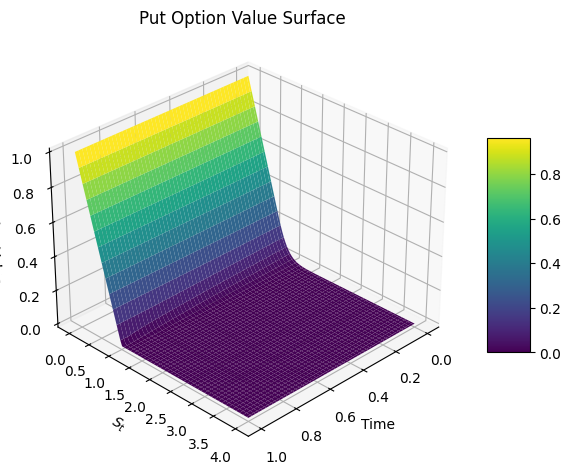

In [46]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

tt, ss = np.meshgrid(t.cpu(), s.cpu(), indexing="ij")

surf = ax.plot_surface(tt, ss, v.cpu().numpy(), cmap="viridis", edgecolor="none")

ax.set_xlabel("Time")
ax.set_ylabel("$S_t$")
ax.set_zlabel("Option Value")
ax.set_title("Put Option Value Surface")

# Rotate the view - adjust elevation and azimuth angles
ax.view_init(elev=30, azim=45)

plt.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()

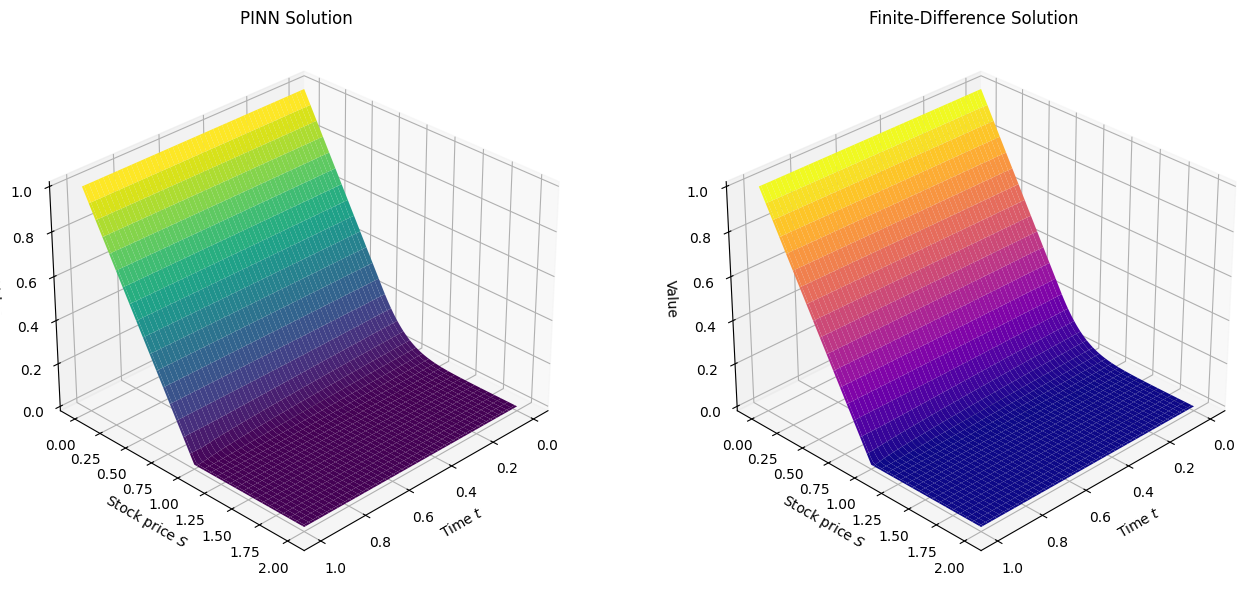

In [47]:
nas = 100  # space steps
v_fd, s_fd, t_fd = option_value_fd_american(
    SIGMA, r, STRIKE, T, option_type="put", nas=nas
)
v_fd = np.flipud(v_fd.T) 

tau_grid = 1.0 - torch.tensor(t_fd, dtype=DTYPE, device=DEV) / T
S_grid_t = torch.tensor(s_fd, dtype=DTYPE, device=DEV)

tau, S = torch.meshgrid(tau_grid, S_grid_t, indexing="ij")
x_grid = S

with torch.no_grad():
    Xg = torch.stack([tau.reshape(-1), x_grid.reshape(-1)], dim=1)
    V_pinn_grid = model(Xg).reshape(tau.shape)


V_pinn_np = V_pinn_grid.cpu().numpy()
err_np = np.abs(V_pinn_np - v_fd)  # |error|
TT, SS = np.meshgrid(t_fd, s_fd, indexing="ij")  # for 3-D axes

fig1 = plt.figure(figsize=(14, 6))

ax1 = fig1.add_subplot(1, 2, 1, projection="3d")
surf1 = ax1.plot_surface(TT, SS, V_pinn_np, cmap=cm.viridis, edgecolor="none")
ax1.set_title("PINN Solution")
ax1.set_xlabel("Time $t$")
ax1.set_ylabel("Stock price $S$")
ax1.set_zlabel("Value")
ax1.view_init(elev=30, azim=45)

ax2 = fig1.add_subplot(1, 2, 2, projection="3d")
surf2 = ax2.plot_surface(TT, SS, v_fd, cmap=cm.plasma, edgecolor="none")
ax2.set_title("Finite-Difference Solution")
ax2.set_xlabel("Time $t$")
ax2.set_ylabel("Stock price $S$")
ax2.set_zlabel("Value")
ax2.view_init(elev=30, azim=45)

fig1.tight_layout()
plt.show()

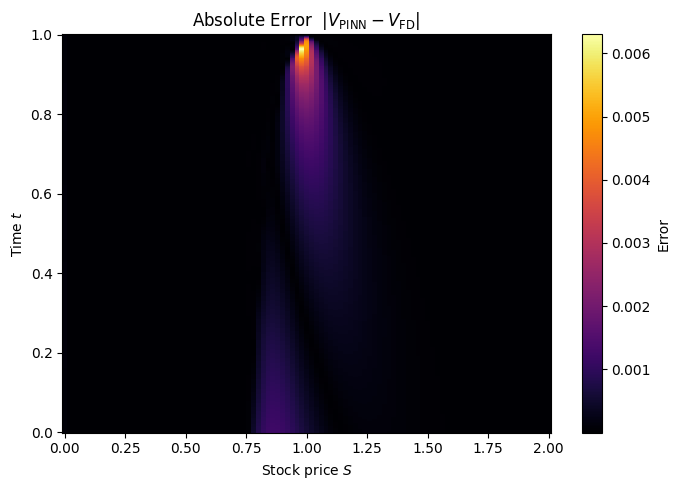

In [48]:
fig2, ax_err = plt.subplots(figsize=(7, 5))
pcm = ax_err.pcolormesh(SS, TT, err_np, shading="auto", cmap="inferno")
ax_err.set_title(r"Absolute Error  $|V_{\mathrm{PINN}}-V_{\mathrm{FD}}|$")
ax_err.set_xlabel("Stock price $S$")
ax_err.set_ylabel("Time $t$")
fig2.colorbar(pcm, ax=ax_err, label="Error")
fig2.tight_layout()
plt.show()

In [49]:
print(
    f"Relative L2 error: {np.linalg.norm(V_pinn_np - v_fd, ord=2) / np.linalg.norm(v_fd, ord=2):.4e}"
)
print(f"Mean Squared Error: {np.mean((V_pinn_np - v_fd)**2):.4e}")

Relative L2 error: 8.0427e-04
Mean Squared Error: 1.4456e-07


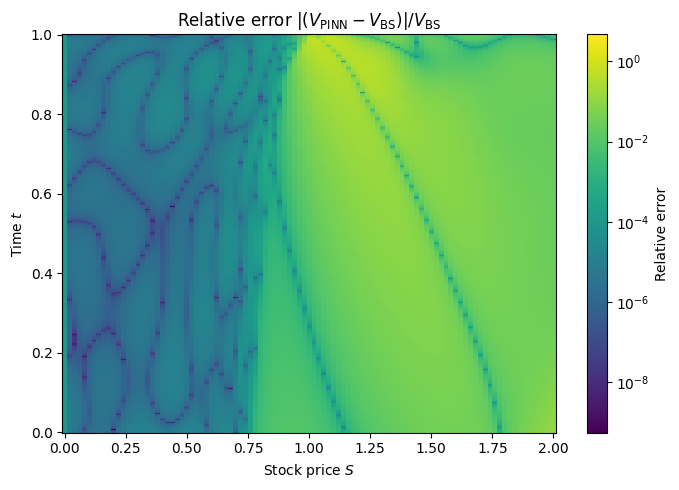

In [50]:
import matplotlib.colors as mcolors

eps = 1e-4  
den = np.maximum(np.abs(v_fd), eps)
rel_err_np = np.abs(V_pinn_np - v_fd) / den
rel_err_pct = 100 * rel_err_np


fig3 = plt.figure(figsize=(7, 5))
ax3 = fig3.add_subplot(111)

log_norm = mcolors.LogNorm(
    vmin=np.nanmin(rel_err_np[rel_err_np > 0]), vmax=np.nanmax(rel_err_np)
)

cmesh = ax3.pcolormesh(
    SS, TT, rel_err_np, shading="auto", cmap="viridis", norm=log_norm
)  

ax3.set_title(
    r"Relative error $|(V_{\mathrm{PINN}}-V_{\mathrm{BS}})| / V_{\mathrm{BS}}$"
)
ax3.set_xlabel("Stock price $S$")
ax3.set_ylabel("Time $t$")

cb = fig3.colorbar(cmesh, ax=ax3, label="Relative error")
cb.update_ticks()

fig3.tight_layout()
plt.show()

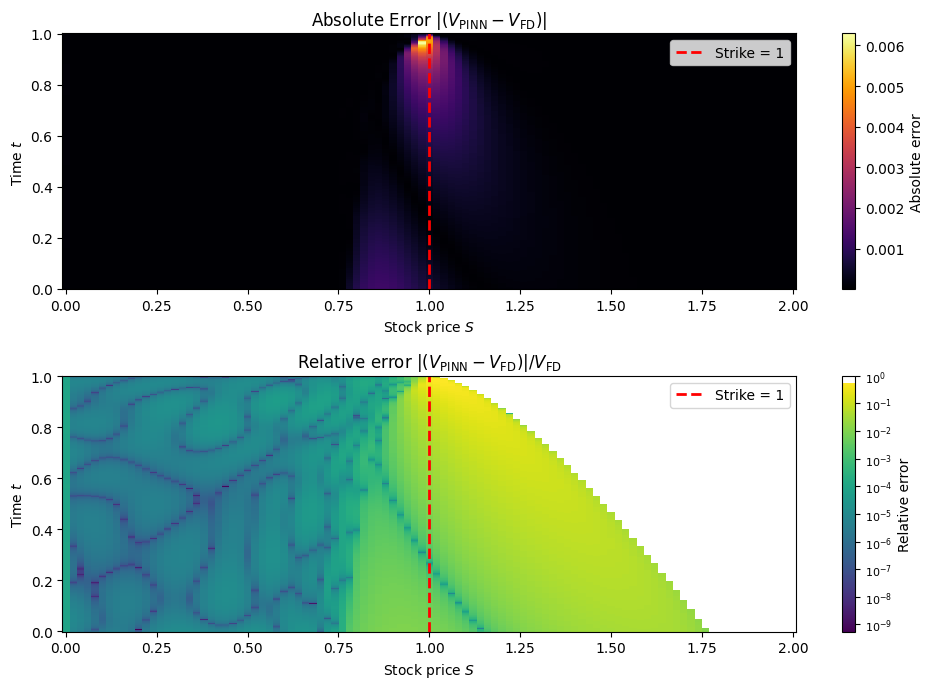

In [51]:
# Create figure with proper size for subplots
fig2 = plt.figure(figsize=(10, 7))

rel_err_np = np.abs(V_pinn_np - v_fd) / np.where(np.abs(v_fd) > eps, v_fd, np.nan)
rel_err_pct = 100 * rel_err_np

# Absolute error plot
ax1 = fig2.add_subplot(2, 1, 1)
cmesh1 = ax1.pcolormesh(SS, TT, err_np, cmap="inferno")
ax1.set_title(r"Absolute Error $|(V_{\mathrm{PINN}}-V_{\mathrm{FD}})|$")
ax1.set_xlabel("Stock price $S$")
ax1.set_ylabel("Time $t$")
ax1.axvline(
    x=STRIKE, color="red", linestyle="--", linewidth=2, label=f"Strike = {STRIKE}"
)
ax1.legend()
fig2.colorbar(cmesh1, ax=ax1, label="Absolute error")

# Relative error plot
ax2 = fig2.add_subplot(2, 1, 2)
# Filter out zero/nan values for better log normalization
valid_rel_err = rel_err_np[~np.isnan(rel_err_np) & (rel_err_np > 0)]
if len(valid_rel_err) > 0:
    log_norm = mcolors.LogNorm(vmin=np.min(valid_rel_err), vmax=np.max(valid_rel_err))
else:
    log_norm = None

cmesh2 = ax2.pcolormesh(SS, TT, rel_err_np, cmap="viridis", norm=log_norm)
ax2.set_title(
    r"Relative error $|(V_{\mathrm{PINN}}-V_{\mathrm{FD}})| / V_{\mathrm{FD}}$"
)
ax2.set_xlabel("Stock price $S$")
ax2.set_ylabel("Time $t$")
ax2.axvline(
    x=STRIKE, color="red", linestyle="--", linewidth=2, label=f"Strike = {STRIKE}"
)
ax2.legend()

# Create colorbar with fewer ticks to avoid overlap
cb = fig2.colorbar(cmesh2, ax=ax2, label="Relative error")
if log_norm is not None:
    cb.ax.tick_params(labelsize=8)  # Smaller font size
    # Manually set fewer tick locations if needed
    cb.set_ticks(
        [
            10**i
            for i in range(
                int(np.log10(np.min(valid_rel_err))),
                int(np.log10(np.max(valid_rel_err))) + 1,
            )
        ]
    )

plt.tight_layout()
plt.show()

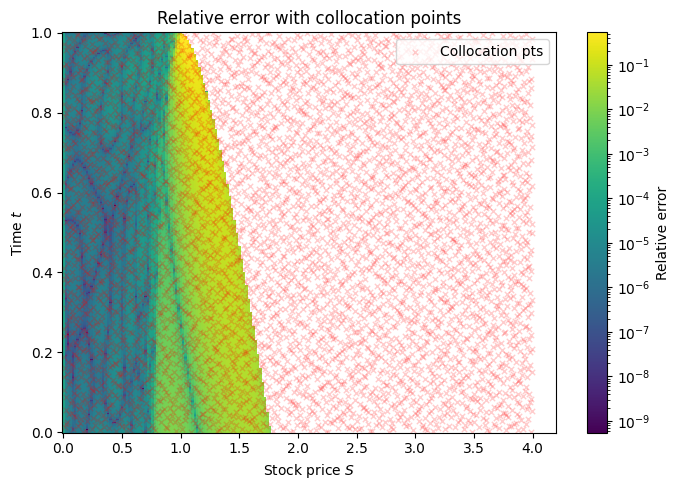

In [ ]:

with torch.no_grad():
    tau_col = X[:, 0].cpu().numpy()  # τ = time-to-expiry     ∈ [0, T]
    x_col = X[:, 1].cpu().numpy()  # log-moneyness

interior_mask = (tau_col > 0.0) & (tau_col < T) & (x_col > X_MIN) & (x_col < X_MAX)

tau_col = tau_col[interior_mask]
x_col = x_col[interior_mask]

t_col = T - tau_col  
S_col = x_col  

n_plot = 20_000  # show this many points at most
if len(t_col) > n_plot:
    sel = np.random.choice(len(t_col), n_plot, replace=False)
    t_col, S_col = t_col[sel], S_col[sel]

# ── 3)  Draw the figure ──────────────────────────────────────────────────
fig_cp, ax_cp = plt.subplots(figsize=(7, 5))

# heat-map background (reuse rel_err_np and log_norm from previous block)
pcm = ax_cp.pcolormesh(
    SS, TT, rel_err_np, shading="auto", cmap="viridis", norm=log_norm
)

# overlay collocation points
ax_cp.scatter(
    S_col,
    t_col,
    marker="x",
    color="red",
    s=15,
    linewidths=1.0,
    alpha=0.2,
    label="Collocation pts",
)

ax_cp.set_title(r"Relative error with collocation points")
ax_cp.set_xlabel("Stock price $S$")
ax_cp.set_ylabel("Time $t$")
ax_cp.legend()

fig_cp.colorbar(pcm, ax=ax_cp, label="Relative error")
plt.tight_layout()
plt.show()

In [53]:
# ─────────────── Greeks on a (t,S) grid ──────────────────────────
s_plot = torch.linspace(X_MIN, X_MAX, 200, device=DEV)
t_plot = torch.tensor([0.00 * T, 0.25 * T, 0.50 * T, 0.75 * T, 1.00 * T], device=DEV)

tau_mesh, S_mesh = torch.meshgrid(T - t_plot, s_plot, indexing="ij")
X_mesh = torch.stack([tau_mesh.reshape(-1), S_mesh.reshape(-1)], dim=1).to(DEV)
X_mesh.requires_grad_(True)

V_flat = model(X_mesh)  # option value
grads = torch.autograd.grad(V_flat.sum(), X_mesh, create_graph=True)[0]
V_tau_flat, V_S_flat = grads[:, 0], grads[:, 1]  # ∂V/∂τ , ∂V/∂S
V_SS_flat = torch.autograd.grad(V_S_flat.sum(), X_mesh)[0][:, 1]  # ∂²V/∂S²

nt, ns = len(t_plot), len(s_plot)
V = V_flat.reshape(nt, ns).detach().cpu().numpy()
Delta = V_S_flat.reshape(nt, ns).detach().cpu().numpy()
Gamma = V_SS_flat.reshape(nt, ns).detach().cpu().numpy()
Theta = (-V_tau_flat).reshape(nt, ns).detach().cpu().numpy()

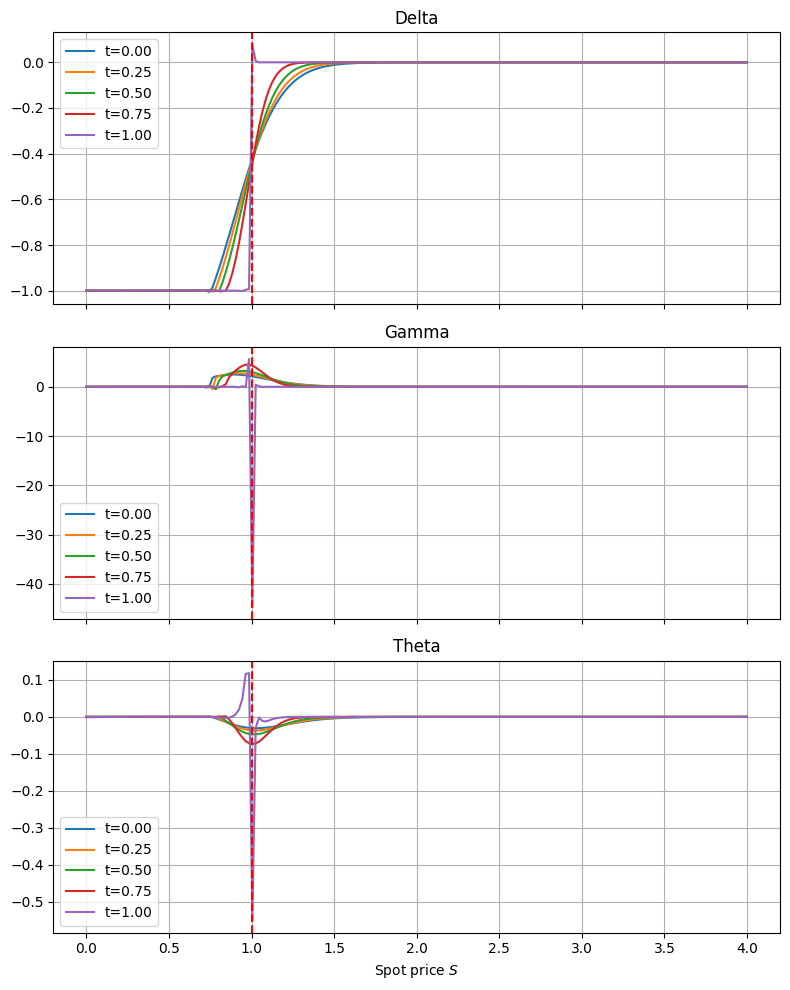

: 

In [ ]:
# ─────────────── Plot Δ, Γ, Θ at selected times ───────────────────
labels = [f"t={t.item():.2f}" for t in t_plot.cpu()]

fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

for k, lab in enumerate(labels):
    axs[0].plot(s_plot.cpu(), Delta[k], label=lab)
    axs[1].plot(s_plot.cpu(), Gamma[k], label=lab)
    axs[2].plot(s_plot.cpu(), Theta[k], label=lab)

axs[0].set_title("Delta")
axs[1].set_title("Gamma")
axs[2].set_title("Theta")

for ax in axs:
    ax.axvline(STRIKE, color="red", ls="--")  # mark strike
    ax.grid(True)
    ax.legend()

axs[-1].set_xlabel("Spot price $S$")
plt.tight_layout()
plt.show()